In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import normalize
plt.rcParams["figure.figsize"] = (5,4)
plt.rcParams["figure.dpi"] = 150
TICK_SIZE = 12
AXES_SIZE = 14
TITLE_SIZE = 14
FACECOLOR = 'white'
SCATTER_ALPHA = 0.5

plt.rc('font', size=TICK_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=AXES_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=AXES_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=TICK_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=TICK_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=TICK_SIZE)    # legend fontsize
plt.rc('figure', titlesize=TITLE_SIZE)  # fontsize of the figure title


In [2]:
# loads data and makes the uh you know the thing. 
# yeah
data_folder = 'numpy_data/'
feature_qos = np.load(data_folder + 'features_qos.npy')
r_labels = np.load(data_folder + 'r_labels.npy')
p_labels = np.load(data_folder + 'p_labels.npy')

data_folder = 'numpy_data/'
feature_data = np.load(data_folder + 'sim_features.npy')

In [31]:
low_p_label = p_labels-r_labels
high_p_label = p_labels+r_labels

p_low_lin_reg_all = LinearRegression().fit(feature_qos, low_p_label)
p_high_lin_reg_all = LinearRegression().fit(feature_qos, high_p_label)
p_low_lin_reg_pred_all = p_low_lin_reg_all.predict(feature_qos)
p_high_lin_reg_pred_all = p_high_lin_reg_all.predict(feature_qos)
print('P Low MAE:',sklearn.metrics.mean_absolute_error(low_p_label,p_low_lin_reg_pred_all))
print('R High MAE:',sklearn.metrics.mean_absolute_error(high_p_label,p_high_lin_reg_pred_all))
print('P Low:',p_low_lin_reg_all.score(feature_qos,low_p_label))
print('R High:',p_high_lin_reg_all.score(feature_qos,high_p_label))

P Low MAE: 4609.03798185941
R High MAE: 6368.245023935499
P Low: 0.8569701972596816
R High: 0.8499700419790972


Text(0, 0.5, 'Power [W]')

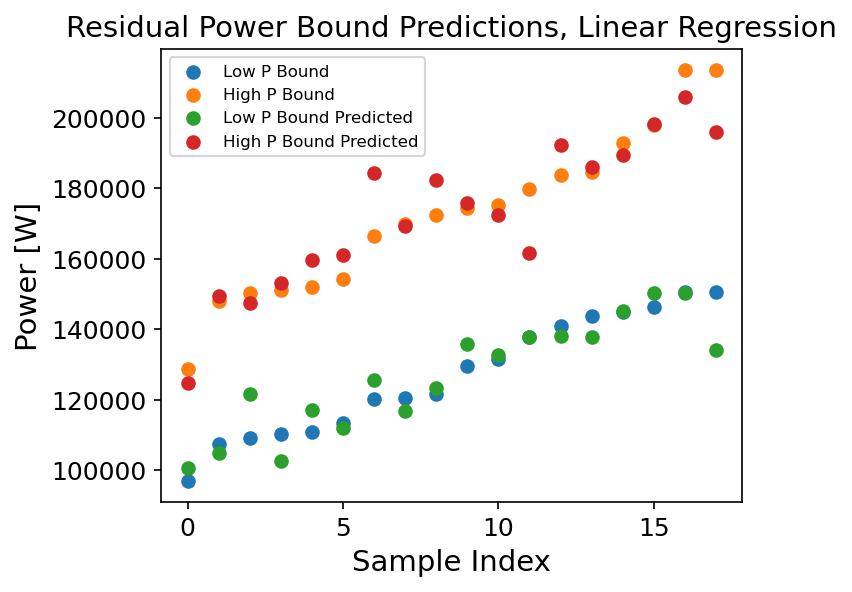

In [37]:
low_sort_index = np.argsort(low_p_label)
high_sort_index = np.argsort(high_p_label)
low_p_label = np.take_along_axis(low_p_label,low_sort_index,axis=0)
high_p_label = np.take_along_axis(high_p_label,high_sort_index,axis=0)
p_low_lin_reg_pred_all = np.take_along_axis(p_low_lin_reg_pred_all,low_sort_index,axis=0)
p_high_lin_reg_pred_all = np.take_along_axis(p_high_lin_reg_pred_all,high_sort_index,axis=0)


plt.scatter(range(len(low_p_label)),low_p_label,label='Low P Bound')
plt.scatter(range(len(high_p_label)),high_p_label,label='High P Bound')

plt.scatter(range(len(p_low_lin_reg_pred_all)),p_low_lin_reg_pred_all,label='Low P Bound Predicted')
plt.scatter(range(len(p_high_lin_reg_pred_all)),p_high_lin_reg_pred_all,label='High P Bound Predicted')
#plt.legend(loc='lower right')
plt.legend(prop={'size': 8})

plt.title('Residual Power Bound Predictions, Linear Regression')
plt.xlabel('Sample Index')
plt.ylabel('Power [W]')